In [24]:
from sdk_core import configure
from sdk_core import TwMarketData
# configure()

tw = TwMarketData()
# 取得還原股價
df = tw.get_security_price_adjusted("2025-12-31", "2330")

import os
import numpy as np
from tqdm import tqdm
import time
import datetime
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
# 將最大顯示欄位數量設為 None（代表無上限）
pd.set_option('display.max_columns', None)

import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

import pyarrow as pa
schema = pa.schema([
    ('price', pa.decimal128(10, 4)), 
    # 其他欄位如果沒特別指定，pyarrow 會自動推斷
])

from backTest import BackTest
from factorAnalyzer import FactorAnalyzer_Polars


In [25]:

folder_path = './data'  # 資料夾路徑
files = os.listdir(folder_path)

# 過濾掉資料夾，只留下檔案
file_names = np.array([f for f in files if os.path.isfile(os.path.join(folder_path, f))])
file_names.sort()
print(file_names[-5:])

['20260311.parquet' '20260312.parquet' '20260313.parquet'
 '20260316.parquet' '20260317.parquet']


In [26]:
data = []

# 範例：處理 100 個檔案
for f in tqdm (file_names[750:]): 
    targetLabel = 'BidPrice1' 
    rankThres_btn = 0
    rankThres = 100.1
    stock_df = pd.read_parquet( f'{folder_path}/{f}' )[lambda x : x[targetLabel] * x.BidPrice1 > 0]
    try : 
        stock_df['ToRef'] = ((stock_df['BidPrice1'] - stock_df.RefPrice) / stock_df.RefPrice ).round(4)
        # stock_df['TakerSell_CloseBP'] = ((stock_df[targetLabel]- stock_df.Close) / stock_df[targetLabel] * 10000)
        # stock_df.loc[ stock_df.FutureHigh > stock_df.RefPrice*1.09 , 'TakerSell_CloseBP'] = ((stock_df[targetLabel] - stock_df.FutureHigh) / stock_df[targetLabel] * 10000)
        stock_df['TakerSell_CloseBP'] = ((stock_df[targetLabel]- stock_df.Close) / stock_df[targetLabel] * 10000)
        stock_df.loc[ stock_df.FutureHigh > stock_df.RefPrice*1.08 , 'TakerSell_CloseBP'] = ((stock_df[targetLabel] - stock_df.RefPrice*1.08 - stock_df.TickSize*2) / stock_df[targetLabel] * 10000)
        PriceCondition = (stock_df.ToRef > 0) & (stock_df.ToRef < 0.05)
        # seqCondition = (stock_df.BidPrice1.diff()!= 0)
        AmountCondition = (stock_df.day_amount_rank <= rankThres) | (stock_df.AmountRank <= rankThres) 
        # AmountCondition2 = (stock_df.day_amount_rank > rankThres_btn) & (stock_df.AmountRank > rankThres_btn)
        # preMarketCondition = (stock_df.day_amount_rank <= 50.1) | (stock_df.AmountRank <= 50.1)
        temp = stock_df[ PriceCondition & AmountCondition].reset_index(drop=True)
        temp['Date'] = f.split('.')[0]
        data.append(temp)
    except : 
        print('Filled in ', f)
        continue
        # break       
    # if f.split('.')[0] == '20260309':
    #     break

100%|██████████| 18/18 [00:01<00:00,  9.76it/s]


In [48]:
signal_df = pd.concat(data).reset_index(drop=True)

In [49]:
priceReturnColumn = ["TransTime", "QuoteCode", "ChannelSeq","TotalFillLots","BidPrice1","BidLots1", "AskPrice1","AskLots1", "RecordHigh","FutureHigh", "RefPrice" , "Close" , "Open", "Spread", "TakerSell_CloseBP" ]
signal_df[:][priceReturnColumn + ['ToRef','FillLots_atLow','day_amount_rank', 'AmountRank', 'TimeSlot','TransTime_tb']].head(10)

,TransTime,QuoteCode,ChannelSeq,TotalFillLots,BidPrice1,BidLots1,AskPrice1,AskLots1,RecordHigh,FutureHigh,RefPrice,Close,Open,Spread,TakerSell_CloseBP,ToRef,FillLots_atLow,day_amount_rank,AmountRank,TimeSlot,TransTime_tb
0,2026-02-10 09:00:01.084800,1303,101606,1137,78.6,82,78.8,106,78.8,78.7,78.0,72.8,78.8,2.0,737.913486,0.0077,-9,35.0,NaN,None,NaT
1,2026-02-10 09:00:01.108136,1303,101685,1148,78.6,82,78.8,114,78.8,78.7,78.0,72.8,78.8,2.0,737.913486,0.0077,-4,35.0,NaN,None,NaT
2,2026-02-10 09:00:01.118252,1303,101709,1230,78.5,149,78.7,7,78.8,78.7,78.0,72.8,78.8,2.0,726.114650,0.0064,-81,35.0,NaN,None,NaT
3,2026-02-10 09:00:01.153319,1303,101801,1378,78.4,41,78.6,5,78.8,78.7,78.0,72.8,78.8,2.0,714.285714,0.0051,-147,35.0,NaN,None,NaT
4,2026-02-10 09:00:01.168700,1303,101810,1378,78.5,1,78.6,5,78.8,78.7,78.0,72.8,78.8,1.0,726.114650,0.0064,-147,35.0,NaN,None,NaT
5,2026-02-10 09:00:01.185698,1303,101862,1420,78.3,78,78.6,11,78.8,78.7,78.0,72.8,78.8,3.0,702.426564,0.0038,-42,35.0,NaN,None,NaT
6,2026-02-10 09:00:01.219560,1303,101925,1501,78.2,33,78.5,14,78.8,78.7,78.0,72.8,78.8,3.0,690.537084,0.0026,-71,35.0,NaN,None,NaT
7,2026-02-10 09:00:01.252036,1303,101985,1501,78.4,2,78.5,14,78.8,78.7,78.0,72.8,78.8,1.0,714.285714,0.0051,-71,35.0,NaN,None,NaT
8,2026-02-10 09:00:01.254482,1303,101990,1503,78.2,31,78.5,14,78.8,78.7,78.0,72.8,78.8,3.0,690.537084,0.0026,-73,35.0,NaN,None,NaT
9,2026-02-10 09:00:05.167086,1303,107283,1553,78.1,86,78.3,14,78.8,78.7,78.0,72.8,78.8,2.0,678.617157,0.0013,-14,35.0,NaN,None,NaT


In [50]:
# target_time_str = "13:25:00"
# target_dt = pd.to_datetime(signal_df['TransTime'].dt.date.astype(str) + " " + target_time_str)
# signal_df['RemainSeconds'] = (target_dt - signal_df['TransTime']).dt.total_seconds()
signal_df = signal_df[ (signal_df.TransTime.dt.time < datetime.time(12, 0, 0)) & (signal_df.TrialMatch == 0)].reset_index(drop=True)
signal_df = signal_df[  ((signal_df.Date.astype(int) - 20260220).abs() > 5 )& (signal_df.TakerSell_CloseBP.abs() < 10000) ].reset_index(drop=True)
# signal_df = signal_df[  (signal_df.TakerSell_CloseBP.abs() < 10000) ].reset_index(drop=True)
signal_df['midEdge_300sBP'] = signal_df['midEdge_300sBP']*-1

In [51]:
signal_df.head(1)

,RecvTime,TransTime,QuoteCode,ValueCode,PacketSeq,ChannelSeq,LimitStatus,TrialMatch,InOut,Overshoot,TotalFillLots,BidPrice1,BidPrice2,BidPrice3,BidPrice4,BidPrice5,BidLots1,BidLots2,BidLots3,BidLots4,BidLots5,AskPrice1,AskPrice2,AskPrice3,AskPrice4,AskPrice5,AskLots1,AskLots2,AskLots3,AskLots4,AskLots5,FillPrice,FillLots,BestBidPrice,BestBidLots,BestAskPrice,BestAskLots,OvershootHis,RefPrice,OTC,marketOpen,Open,Close,RecordHigh,RecordLow,FutureHigh,FutureLow,ToLow,ToHigh,Low_High,BidPreMove,AskPreMove,TickSize,TickBP,MidPrice,ToRef,ToOpen,FillLots_atLow,FillLots_atHigh,FillLots_Net,B1_A1B1,B1_B1B5,B12_B1B5,A1_A1A5,A12_A1A5,Spread,SpreadPairID,SpreadPairAsk,SpreadPairBid,SpreadPairSeq,SpreadPairElapsed,SpreadNarrowOrderTime,SpreadNarrowSide,SpreadPairCumLots,PrevSpreadPairLots,RemainSeconds,FutureAsk1_5s,FutureBid1_5s,FutureAsk1_30s,FutureBid1_30s,FutureAsk1_60s,FutureBid1_60s,FutureAsk1_120s,FutureBid1_120s,FutureAsk1_300s,FutureBid1_300s,FutureAsk1_600s,FutureBid1_600s,TakerSell_CloseBP,TakerBuy_CloseBP,midEdge_5sBP,midEdge_30sBP,midEdge_60sBP,midEdge_120sBP,midEdge_300sBP,midEdge_600sBP,allow_day_trade_mark,trading_volume,dealer_hedging_netLots,dealer_netLots,foreign_dealer_netLots,foreign_netLots,investment_netLots,margin_netLots,short_netLots,nextday_allow_day_trade_mark,trading_volume_noOdd,trading_net_volume_noOdd,trading_net_volume_nearClose,avg_bidLots1,avg_askLots1,last_fillLots,last_FillPrice,big_buy_lots,big_buy_ToCloseBP,big_buy_300sBP,big_sell_lots,big_sell_ToCloseBP,big_sell_300sBP,hft_participation,hft_buy_ToCloseBP,hft_buy_300sBP,hft_sell_ToCloseBP,hft_sell_300sBP,negFill_corr,negFill_sell_ToCloseBP,negFill_sell_300sBP,premium_ref_2330_buy_ToCloseBP,premium_open_2330_buy_ToCloseBP,discount_ref_2330_buy_ToCloseBP,discount_open_2330_buy_ToCloseBP,day_amount_rank,day_lots_rank,TransTime_tb,TimeSlot,AmountRank,netAmountRank,TotalFillLotsRank,netTotalFillLotsRank,ToRefRank,ToOpenRank,ToRefWithOTCRank,ToOpenWithOTCRank,ToOpenNegativeCount,ToOpenPositiveCount,Date,FillLots_origin
0,2026-02-10 01:00:31.730425,2026-02-10 09:00:01.084800,1303,1303,4725809,101606,0,0,-1,0,1137,78.6,78.5,78.4,78.3,78.2,82,147,38,76,37,78.8,78.9,79.0,79.1,79.2,106,72,138,44,15,78.7,22,0.0,0,0.0,0,NaN,78.0,False,True,78.8,72.8,78.8,78.7,78.7,72.2,0.0,0.001282,0.0,-0.1,0.0,0.1,12.722646,78.7,0.0077,-0.001269,-9,-1097,-1097,0.43617,0.215789,0.602632,0.282667,0.474667,2.0,1,78.8,78.6,1,0.0,0.01121,-1.0,22,1115,15898,78.0,77.8,77.1,77.0,77.0,76.9,76.7,76.6,77.8,77.7,78.4,78.3,737.913486,-761.42132,-101.651842,-209.656925,-222.363405,-260.482846,120.711563,-44.472681,X,107011207.0,1646577.0,789427.0,0.0,24776196.0,-862000.0,1457.0,-138.0,X,106195.0,-45684.0,-64837.0,77.984885,140.746845,3317.0,-0.000641,24.0,-47.895439,-1.10412,16.0,-148.217765,-1.013593,0.605609,12.110747,-6.160957,-248.484492,19.471926,-0.998403,-505.492722,-92.795749,-43.701733,-65.9899,NaN,185.119512,35.0,15.0,NaT,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20260210,NaN


<Axes: xlabel='Date'>

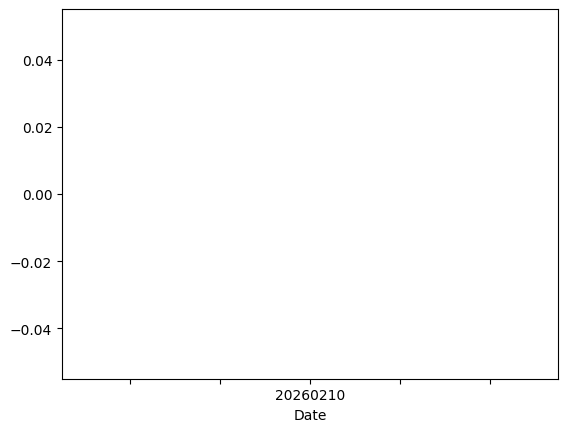

In [52]:
signal_df[:].groupby(['Date','QuoteCode']).TakerSell_CloseBP.mean().reset_index().groupby(['Date']).TakerSell_CloseBP.mean().rolling(30).mean().plot()

In [53]:
signal_df['TakerSell_CloseBP_net'] = signal_df.TakerSell_CloseBP - signal_df.groupby('Date').TakerSell_CloseBP.transform('mean')

In [54]:
signal_df.TakerSell_CloseBP .describe()

count    189206.000000
mean         56.086957
std         401.376773
min        -844.230769
25%        -176.125245
50%          54.945055
75%         318.471338
max        1196.172249
Name: TakerSell_CloseBP, dtype: float64

# ================= 使用範例 =================
# 假設 df 是您準備好的 Tick 資料
based_columns = ['QuoteCode', 'ChannelSeq', 'InOut', 'Overshoot', 'TotalFillLots', 'BidPrice1','BidLots1', 'BidLots5', 'AskPrice1', 'AskLots1', 'AskLots5', 'FillLots']
feature_columns = ['ToLow', 'ToHigh', 'Low_High', 'TickSize', 'TickBP', 'ToRef', 'ToOpen', 'FillLots_atLow', 'FillLots_atHigh', 'B1_A1B1', 'B1_B1B5', 'B12_B1B5', 'A1_A1A5', 'A12_A1A5', 'Spread', 'SpreadPairID', 'SpreadPairSeq', 'SpreadPairElapsed', 'SpreadNarrowSide', 'SpreadPairCumLots', 'PrevSpreadPairLots', 'RemainSeconds']
cross_columns = ['AmountRank', 'netAmountRank', 'TotalFillLotsRank', 'netTotalFillLotsRank', 'ToRefRank']
day_columns = ['dealer_hedging_netLots', 'dealer_netLots', 'foreign_dealer_netLots', 'foreign_netLots', 'investment_netLots', 'margin_netLots', 'short_netLots', 'nextday_allow_day_trade_mark', 'trading_volume_noOdd', 'big_buy_lots', 'big_buy_ToCloseBP', 'big_buy_300sBP', 'big_sell_lots', 'big_sell_ToCloseBP', 'big_sell_300sBP', 'hft_participation', 'hft_buy_ToCloseBP', 'hft_buy_300sBP', 'hft_sell_ToCloseBP', 'hft_sell_300sBP', 'day_amount_rank', 'day_lots_rank']
# # 
feature = based_columns + feature_columns + cross_columns + day_columns

for label in [ 'TakerSell_CloseBP_net', 'midEdge_300sBP' ] : 
    analyzer = FactorAnalyzer_Polars(signal_df, label_col=label, feature_cols=feature, time_col='Date', weight_col='BidPrice1')
    top_factors_df = analyzer.screen_single_factors(split_date='2024-01-01', n_quantiles=5, spread_threshold=40.0)
    condition_sample = (top_factors_df.Stability > 0.5) & (top_factors_df.IS_Spread * top_factors_df.IS_IC.apply(np.sign) > 40 )
    condition_weight = (top_factors_df.W_Stability > 0.5) & (top_factors_df.IS_W_Spd * top_factors_df.IS_W_IC.apply(np.sign) > 40 )
    top_factors = top_factors_df[ condition_sample | condition_weight ].Feature.to_list()
    break
    # signal_df = train_and_predict_ridge(signal_df, top_factors, label, train_date='2025-01-01')

import pandas as pd
from sklearn.linear_model import Ridge

def train_and_predict_ridge(signal_df, X_list, Y_col):
    print(f"🔍 目前預測目標: {Y_col}")
    
    # 計算 0.1% 的閾值 (threshold)
    total_rows = len(signal_df)
    threshold = total_rows * 0.01
    print(f"📊 資料總筆數: {total_rows} | 0.1% 容忍閾值: {threshold:.2f} 筆")
    
    # 建立分類清單
    cols_to_drop_rows = []
    cols_to_remove_from_X = []
    
    # ==========================================
    # 1. 檢查 X_list 裡面的 NaN 狀況並分類
    # ==========================================
    for col in X_list:
        nan_count = signal_df[col].isna().sum()
        if nan_count > 0:
            if nan_count < threshold:
                # NaN 數量小於 0.1%，標記為準備 dropna (刪除資料列)
                cols_to_drop_rows.append(col)
            else:
                # NaN 數量大於等於 0.1%，標記為準備移除特徵
                cols_to_remove_from_X.append(col)
                
    # ==========================================
    # 2. 執行移除特徵 (Columns) 動作
    # ==========================================
    # 產生真正要進模型的 current_X
    current_X = [col for col in X_list if col not in cols_to_remove_from_X]
    
    if cols_to_remove_from_X:
        print(f"⚠️ 以下特徵 NaN 數量超過閾值，已從 X_list 中移除：")
        for col in cols_to_remove_from_X:
            nan_count = signal_df[col].isna().sum()
            print(f"   - {col} (NaN: {nan_count} 筆)")
            
    # ==========================================
    # 3. 處理 Y 的 NaN 與執行 dropna (刪除資料列)
    # ==========================================
    # 確保 Y 如果有 NaN 也一併剔除該筆資料
    signal_df.replace([np.inf, -np.inf], np.nan, inplace=True)
    
    if signal_df[Y_col].isna().sum() > 0 and Y_col not in cols_to_drop_rows:
        cols_to_drop_rows.append(Y_col)
        
    if cols_to_drop_rows:
        print(f"🧹 以下欄位 NaN 數量極少 (低於閾值)，將直接剔除帶有 NaN 的資料列：")
        for col in cols_to_drop_rows:
            nan_count = signal_df[col].isna().sum()
            print(f"   - {col} (NaN: {nan_count} 筆)")
            
        # 實際執行 dropna，並更新 signal_df
        signal_df = signal_df.dropna(subset=cols_to_drop_rows).copy()
        print(f"✅ 剔除後剩餘資料總筆數: {len(signal_df)}")
        
    # ==========================================
    # 4. 顯示最終要進模型的 X_list
    # ==========================================
    print("-" * 40)
    print(f"🚀 最終使用的 X_list (共 {len(current_X)} 個特徵):")
    print(current_X)
    print("-" * 40)
    
    # 安全機制：如果所有 X 都被砍光了，就拋出錯誤
    if not current_X:
        raise ValueError("所有的 X 特徵都因為 NaN 太多被移除了，無法建立模型！")

    # ==========================================
    # 5. 處理時間與切分訓練集
    # ==========================================
    train_mask = signal_df['Date'].astype(int) < 20240101
    lot_mask = signal_df.groupby(['Date','QuoteCode']).BidPrice1.cumsum()/10 < 500 
    train_df = signal_df[train_mask&lot_mask]
    
    # ==========================================
    # 6. 建立並訓練 Ridge 模型
    # ==========================================
    model = Ridge(alpha=10.0)
    model.fit(train_df[current_X], train_df[Y_col])
    
    # ==========================================
    # 7. 對整份 signal_df 進行預測
    # ==========================================
    pred_col_name = f"{Y_col}_pred"
    signal_df[pred_col_name] = model.predict(signal_df[current_X])
    
    return signal_df

signal_df = train_and_predict_ridge(signal_df, top_factors, label).reset_index(drop=True)

In [57]:
condition = pd.Series( [True for i in range(len(signal_df))] )
# condition =   (signal_df.ToOpen <0)# (signal_df.Position<200) #(signal_df.big_sell_ToCloseBP > 20 ) & (signal_df.InOut < 0 ) & (signal_df.FillLots > signal_df.big_sell_lots)
# condition = condition | ((signal_df.Spread <= 1 ) & ((signal_df.SpreadPairSeq>5) & (signal_df.SpreadPairID > 5)))
condition = condition #& (signal_df.TakerSell_CloseBP_net_pred > 0) #& ((signal_df.netTotalFillLotsRank>1800)|(signal_df.netAmountRank>1800))
print( signal_df[condition].TakerSell_CloseBP.describe() )
print('')
print( 'cap BP : '+str( round((signal_df[condition].TakerSell_CloseBP * signal_df[condition].BidPrice1).sum() / signal_df[condition].BidPrice1.sum() ,2 ))  )
print( 'averge prod num : '+str( round(signal_df[condition].groupby('Date').QuoteCode.nunique().mean(), 2)  ))

condition_recent = condition & (signal_df.Date.astype(int) > 20260101) #& (signal_df.hft_participation > 0.3) & (signal_df.hft_sell_ToCloseBP > 0 )
print( signal_df[condition_recent].TakerSell_CloseBP.describe() ) 
print('')
print( 'cap BP : '+str( round((signal_df[condition_recent].TakerSell_CloseBP * signal_df[condition_recent].BidPrice1).sum() / signal_df[condition_recent].BidPrice1.sum() ,2 ))  )
print( 'averge prod num : '+str( round(signal_df[condition_recent].groupby('Date').QuoteCode.nunique().mean(), 2)  ))

count    189206.000000
mean         56.086957
std         401.376773
min        -844.230769
25%        -176.125245
50%          54.945055
75%         318.471338
max        1196.172249
Name: TakerSell_CloseBP, dtype: float64

cap BP : -5.74
averge prod num : 64.6
count    189206.000000
mean         56.086957
std         401.376773
min        -844.230769
25%        -176.125245
50%          54.945055
75%         318.471338
max        1196.172249
Name: TakerSell_CloseBP, dtype: float64

cap BP : -5.74
averge prod num : 64.6


In [64]:
signal_df[(signal_df.QuoteCode=='3701') & (signal_df.ChannelSeq >= 10262533)]


,RecvTime,TransTime,QuoteCode,ValueCode,PacketSeq,ChannelSeq,LimitStatus,TrialMatch,InOut,Overshoot,TotalFillLots,BidPrice1,BidPrice2,BidPrice3,BidPrice4,BidPrice5,BidLots1,BidLots2,BidLots3,BidLots4,BidLots5,AskPrice1,AskPrice2,AskPrice3,AskPrice4,AskPrice5,AskLots1,AskLots2,AskLots3,AskLots4,AskLots5,FillPrice,FillLots,BestBidPrice,BestBidLots,BestAskPrice,BestAskLots,OvershootHis,RefPrice,OTC,marketOpen,Open,Close,RecordHigh,RecordLow,FutureHigh,FutureLow,ToLow,ToHigh,Low_High,BidPreMove,AskPreMove,TickSize,TickBP,MidPrice,ToRef,ToOpen,FillLots_atLow,FillLots_atHigh,FillLots_Net,B1_A1B1,B1_B1B5,B12_B1B5,A1_A1A5,A12_A1A5,Spread,SpreadPairID,SpreadPairAsk,SpreadPairBid,SpreadPairSeq,SpreadPairElapsed,SpreadNarrowOrderTime,SpreadNarrowSide,SpreadPairCumLots,PrevSpreadPairLots,RemainSeconds,FutureAsk1_5s,FutureBid1_5s,FutureAsk1_30s,FutureBid1_30s,FutureAsk1_60s,FutureBid1_60s,FutureAsk1_120s,FutureBid1_120s,FutureAsk1_300s,FutureBid1_300s,FutureAsk1_600s,FutureBid1_600s,TakerSell_CloseBP,TakerBuy_CloseBP,midEdge_5sBP,midEdge_30sBP,midEdge_60sBP,midEdge_120sBP,midEdge_300sBP,midEdge_600sBP,allow_day_trade_mark,trading_volume,dealer_hedging_netLots,dealer_netLots,foreign_dealer_netLots,foreign_netLots,investment_netLots,margin_netLots,short_netLots,nextday_allow_day_trade_mark,trading_volume_noOdd,trading_net_volume_noOdd,trading_net_volume_nearClose,avg_bidLots1,avg_askLots1,last_fillLots,last_FillPrice,big_buy_lots,big_buy_ToCloseBP,big_buy_300sBP,big_sell_lots,big_sell_ToCloseBP,big_sell_300sBP,hft_participation,hft_buy_ToCloseBP,hft_buy_300sBP,hft_sell_ToCloseBP,hft_sell_300sBP,negFill_corr,negFill_sell_ToCloseBP,negFill_sell_300sBP,premium_ref_2330_buy_ToCloseBP,premium_open_2330_buy_ToCloseBP,discount_ref_2330_buy_ToCloseBP,discount_open_2330_buy_ToCloseBP,day_amount_rank,day_lots_rank,TransTime_tb,TimeSlot,AmountRank,netAmountRank,TotalFillLotsRank,netTotalFillLotsRank,ToRefRank,ToOpenRank,ToRefWithOTCRank,ToOpenWithOTCRank,ToOpenNegativeCount,ToOpenPositiveCount,Date,FillLots_origin,TakerSell_CloseBP_net,PosLots,Position
180221,2026-03-17 03:52:16.134965,2026-03-17 11:50:54.659019,3701,3701,20358358,10466520,0,0,-1,0,19180,65.1,65.0,64.9,64.8,64.7,38,334,26,123,17,65.3,65.4,65.5,65.6,65.7,8,47,8,7,12,65.2,6,0.0,0,0.0,0,NaN,64.8,False,True,67.6,66.2,69.6,65.1,66.2,65.0,0.003086,0.066358,0.044444,-0.1,0.0,0.1,15.360983,65.20,0.0046,-0.035503,-23,-3353,-2088,0.826087,0.070632,0.691450,0.097561,0.670732,2.0,117,65.3,65.1,5,0.000000,29.682082,1.0,119,97,5645,65.3,65.1,65.3,65.2,65.3,65.2,65.4,65.3,65.5,65.4,65.4,65.3,-168.970814,137.825421,0.000000,7.668712,7.668712,23.006135,-38.343558,23.006135,X,25315298.0,0.0,-63895.0,0.0,1531119.0,0.0,566.0,30.0,X,25196.0,2768.0,1872.0,13.182618,15.484507,673.0,-0.000771,14.0,155.74474,-68.030711,11.0,-309.8171,47.507409,0.687372,242.17456,-64.489071,-301.76166,51.070841,-0.980549,-inf,-inf,161.548524,-21.019929,inf,inf,106.0,51.0,2026-03-17 11:49:58.941656,11:50:00,100.0,1918.0,57.0,1933.0,752.0,1816.0,452.0,1028.0,430.0,466.0,20260317,6.0,-258.023097,974,6533.67
180222,2026-03-17 03:52:45.823376,2026-03-17 11:51:24.341101,3701,3701,20388015,10482346,0,0,0,0,19190,65.2,65.1,65.0,64.9,64.8,4,31,329,25,125,65.3,65.4,65.5,65.6,65.7,11,47,8,7,12,0.0,0,0.0,0,0.0,0,NaN,64.8,False,True,67.6,66.2,69.6,65.1,66.2,65.0,0.003086,0.066358,0.044444,0.1,0.0,0.1,15.337423,65.25,0.0062,-0.034763,-27,-3357,-2092,0.266667,0.007782,0.068093,0.129412,0.682353,1.0,117,65.3,65.1,5,29.682082,29.682082,1.0,129,97,5615,65.3,65.1,65.3,65.2,65.4,65.2,65.5,65.4,65.5,65.3,65.4,65.3,-153.374233,137.825421,-7.662835,0.000000,7.662835,30.651341,-22.988506,15.325670,X,25315298.0,0.0,-63895.0,0.0,1531119.0,0.0,566.0,30.0,X,25196.0,2768.0,1872.0,13.182618,15.484507,673.0,-0.000771,14.0,155.74474,-68.030711,11.0,-309.8171,47.507409,0.687372,242.17456,-64.489071,-301.76166,51.070841,-0.980549,-inf,-inf,161.548524,-21.019929,inf,inf,106.0,51.0,2026-03-17 11:49:58.941656,11:50:00,100.0,1918.0,57.0,1933.0,752.0,1816.0,452.0,10

In [65]:
signal_df = signal_df[condition].reset_index(drop=True)
# signal_df = signal_df[condition & ((signal_df.Date.astype(int) < 20260101) |( (signal_df.hft_participation > 0.3) & (signal_df.hft_sell_ToCloseBP > 0 )))].reset_index(drop=True)


In [66]:
print(signal_df.columns.tolist())

['RecvTime', 'TransTime', 'QuoteCode', 'ValueCode', 'PacketSeq', 'ChannelSeq', 'LimitStatus', 'TrialMatch', 'InOut', 'Overshoot', 'TotalFillLots', 'BidPrice1', 'BidPrice2', 'BidPrice3', 'BidPrice4', 'BidPrice5', 'BidLots1', 'BidLots2', 'BidLots3', 'BidLots4', 'BidLots5', 'AskPrice1', 'AskPrice2', 'AskPrice3', 'AskPrice4', 'AskPrice5', 'AskLots1', 'AskLots2', 'AskLots3', 'AskLots4', 'AskLots5', 'FillPrice', 'FillLots', 'BestBidPrice', 'BestBidLots', 'BestAskPrice', 'BestAskLots', 'OvershootHis', 'RefPrice', 'OTC', 'marketOpen', 'Open', 'Close', 'RecordHigh', 'RecordLow', 'FutureHigh', 'FutureLow', 'ToLow', 'ToHigh', 'Low_High', 'BidPreMove', 'AskPreMove', 'TickSize', 'TickBP', 'MidPrice', 'ToRef', 'ToOpen', 'FillLots_atLow', 'FillLots_atHigh', 'FillLots_Net', 'B1_A1B1', 'B1_B1B5', 'B12_B1B5', 'A1_A1A5', 'A12_A1A5', 'Spread', 'SpreadPairID', 'SpreadPairAsk', 'SpreadPairBid', 'SpreadPairSeq', 'SpreadPairElapsed', 'SpreadNarrowOrderTime', 'SpreadNarrowSide', 'SpreadPairCumLots', 'PrevSprea

In [68]:
## 部位留存
signal_df['PosLots'] = signal_df.groupby(['Date', 'QuoteCode']).BidPrice1.transform('cumcount') + 1
signal_df['Position'] = signal_df.groupby(['Date', 'QuoteCode']).BidPrice1.transform('cumsum') / 10
signalwithRisk_df = signal_df[ (~((signal_df.PosLots >1) & (signal_df.Position > 100))) & (signal_df.BidPrice1<1000)].reset_index(drop=True)
# signalwithRisk_df = signal_df[  (~((signal_df.PosLots >1) & (signal_df.Position > 200))) & (signal_df.BidPrice1<1000)].reset_index(drop=True)
# signalwithRisk_df = signal_df[ (signal_df.PosLots ==1)].reset_index(drop=True)


In [69]:
signalwithRisk_df[signalwithRisk_df.QuoteCode == '3701']

,RecvTime,TransTime,QuoteCode,ValueCode,PacketSeq,ChannelSeq,LimitStatus,TrialMatch,InOut,Overshoot,TotalFillLots,BidPrice1,BidPrice2,BidPrice3,BidPrice4,BidPrice5,BidLots1,BidLots2,BidLots3,BidLots4,BidLots5,AskPrice1,AskPrice2,AskPrice3,AskPrice4,AskPrice5,AskLots1,AskLots2,AskLots3,AskLots4,AskLots5,FillPrice,FillLots,BestBidPrice,BestBidLots,BestAskPrice,BestAskLots,OvershootHis,RefPrice,OTC,marketOpen,Open,Close,RecordHigh,RecordLow,FutureHigh,FutureLow,ToLow,ToHigh,Low_High,BidPreMove,AskPreMove,TickSize,TickBP,MidPrice,ToRef,ToOpen,FillLots_atLow,FillLots_atHigh,FillLots_Net,B1_A1B1,B1_B1B5,B12_B1B5,A1_A1A5,A12_A1A5,Spread,SpreadPairID,SpreadPairAsk,SpreadPairBid,SpreadPairSeq,SpreadPairElapsed,SpreadNarrowOrderTime,SpreadNarrowSide,SpreadPairCumLots,PrevSpreadPairLots,RemainSeconds,FutureAsk1_5s,FutureBid1_5s,FutureAsk1_30s,FutureBid1_30s,FutureAsk1_60s,FutureBid1_60s,FutureAsk1_120s,FutureBid1_120s,FutureAsk1_300s,FutureBid1_300s,FutureAsk1_600s,FutureBid1_600s,TakerSell_CloseBP,TakerBuy_CloseBP,midEdge_5sBP,midEdge_30sBP,midEdge_60sBP,midEdge_120sBP,midEdge_300sBP,midEdge_600sBP,allow_day_trade_mark,trading_volume,dealer_hedging_netLots,dealer_netLots,foreign_dealer_netLots,foreign_netLots,investment_netLots,margin_netLots,short_netLots,nextday_allow_day_trade_mark,trading_volume_noOdd,trading_net_volume_noOdd,trading_net_volume_nearClose,avg_bidLots1,avg_askLots1,last_fillLots,last_FillPrice,big_buy_lots,big_buy_ToCloseBP,big_buy_300sBP,big_sell_lots,big_sell_ToCloseBP,big_sell_300sBP,hft_participation,hft_buy_ToCloseBP,hft_buy_300sBP,hft_sell_ToCloseBP,hft_sell_300sBP,negFill_corr,negFill_sell_ToCloseBP,negFill_sell_300sBP,premium_ref_2330_buy_ToCloseBP,premium_open_2330_buy_ToCloseBP,discount_ref_2330_buy_ToCloseBP,discount_open_2330_buy_ToCloseBP,day_amount_rank,day_lots_rank,TransTime_tb,TimeSlot,AmountRank,netAmountRank,TotalFillLotsRank,netTotalFillLotsRank,ToRefRank,ToOpenRank,ToRefWithOTCRank,ToOpenWithOTCRank,ToOpenNegativeCount,ToOpenPositiveCount,Date,FillLots_origin,TakerSell_CloseBP_net,PosLots,Position
2774,2026-03-05 01:06:04.331045,2026-03-05 09:05:00.217685,3701,3701,5730560,910296,0,0,-1,1,3204,64.4,64.3,64.2,64.1,64.0,22,47,51,32,99,64.6,64.7,64.8,64.9,65.0,16,7,12,9,60,64.4,14,0.0,0,0.0,0,"{""p"":645000,""l"":4}",64.0,False,True,67.4,61.0,67.4,63.8,68.3,57.6,0.010937,0.045313,0.194444,-0.1,0.0,0.1,15.527950,64.50,0.0063,-0.043027,-203,-1032,-1032,0.578947,0.087649,0.274900,0.153846,0.221154,2.0,64,64.6,64.4,3,0.000000,0.442069,1.0,28,5,15599,64.6,64.5,65.5,65.3,66.0,65.8,66.3,66.1,67.5,67.4,65.9,65.8,527.950311,-557.275542,7.751938,139.534884,217.054264,263.565891,-457.364341,209.302326,X,26664633.0,0.0,-102171.0,0.0,1728000.0,0.0,-271.0,41.0,X,26558.0,49820.0,1536.0,10.131613,136.914618,50.0,inf,27.0,inf,776.875678,18.0,-inf,NaN,0.804300,-671.293174,-432.589114,-inf,NaN,-0.127476,-inf,NaN,-1057.992069,-1096.158521,inf,inf,113.0,77.0,2026-03-05 09:04:59.969015,09:05:00,88.0,1953.0,51.0,1967.0,1567.0,1921.0,888.0,1075.0,213.0,607.0,20260305,NaN,269.479420,1,6.44
2775,2026-03-05 01:06:04.772960,2026-03-05 09:05:00.659754,3701,3701,5732013,911305,0,0,0,0,3204,64.5,64.4,64.3,64.2,64.1,1,22,47,51,32,64.6,64.7,64.8,64.9,65.0,16,7,12,9,60,0.0,0,0.0,0,0.0,0,NaN,64.0,False,True,67.4,61.0,67.4,63.8,68.3,57.6,0.009375,0.046875,0.166667,0.1,0.0,0.1,15.503876,64.55,0.0078,-0.042285,-203,-1032,-1032,0.058824,0.006536,0.150327,0.153846,0.221154,1.0,64,64.6,64.4,3,0.442069,0.442069,1.0,28,5,15599,64.6,64.5,65.4,65.3,65.9,65.8,66.3,66.1,67.5,67.4,65.9,65.8,542.635659,-557.275542,0.000000,123.934934,201.394268,255.615802,-449.264136,201.394268,X,26664633.0,0.0,-102171.0,0.0,1728000.0,0.0,-271.0,41.0,X,26558.0,49820.0,1536.0,10.131613,136.914618,50.0,inf,27.0,inf,776.875678,18.0,-inf,NaN,0.804300,-671.293174,-432.589114,-inf,NaN,-0.127476,-inf,NaN,-1057.992069,-1096.158521,inf,inf,113.0,77.0,2026-03-05 09:04:59.969015,09:05:00,88.0,1953.0,51.0,1967.0,1567.0,1921.0,888.0,1075.0,213.0,607.0,20260305,NaN,284.164769,2,

In [43]:
signalwithRisk_df[lambda x : x.Date == '20260317'].reset_index(drop=True).to_csv('20260317_100w.csv')
# signalwithRisk_df[lambda x : x.Date == '20260309'].reset_index(drop=True).to_csv('20260309_oneLots.csv')

In [44]:
signalwithRisk_df[ signalwithRisk_df.Date.astype(int) == signalwithRisk_df.Date.astype(int).max() ].QuoteCode.unique()

<ArrowStringArray>
['1303', '1326', '1717', '1727', '2303', '2313', '2327', '2357', '2368',
 '2382', '2404', '2409', '2421', '2449', '2451', '2455', '2481', '2485',
 '2486', '2605', '2609', '2882', '2884', '3030', '3036', '3037', '3044',
 '3105', '3138', '3163', '3189', '3231', '3363', '3376', '3450', '3481',
 '3583', '3645', '3693', '3701', '3702', '3711', '3714', '4749', '4764',
 '4958', '4967', '4977', '4979', '5314', '5347', '5351', '6197', '6213',
 '6217', '6239', '6274', '6285', '6415', '6531', '6770', '8021', '8046',
 '8096', '8112', '8261', '8996']
Length: 67, dtype: str

In [40]:
signalwithRisk_df[ (signalwithRisk_df.Date.astype(int) == signalwithRisk_df.Date.astype(int).max()) & (signalwithRisk_df.FutureHigh > signalwithRisk_df.RefPrice *1.09) ].QuoteCode.unique()

<ArrowStringArray>
['2313', '2327', '2421', '2451', '2485', '2486', '2605', '3702', '4967',
 '5351', '6197', '6213', '6217', '6531', '6770', '8112']
Length: 16, dtype: str

In [41]:
# 計算所有天數的排名比例
series1 = ( signalwithRisk_df.BidPrice1 * (signalwithRisk_df.TakerSell_CloseBP - 19.3) / 10000 / 10).groupby(signalwithRisk_df.Date).sum()
position = (signalwithRisk_df.BidPrice1 / 10).groupby(signalwithRisk_df.Date).sum()

rank_series = series1.rank(pct=True)

dateSeq = -1

# 取得最後一天的排名
latest_date = series1.index[dateSeq]
latest_rank = rank_series.iloc[dateSeq]

print(f"日期: {latest_date}")
print(f"單邊部位: {position.iloc[dateSeq]:.2f} 萬")
print(f"損益: {series1.iloc[dateSeq]:.2f} 萬")

rank_series = series1.rank()
latest_rank2 = rank_series.iloc[dateSeq]
print(f"排名: {latest_rank2},  {latest_rank :.2%}") # 例如 85.00%，代表贏過歷史 85% 的天數




日期: 20260317
單邊部位: 5703.39 萬
損益: -20.09 萬
排名: 7.0,  46.67%


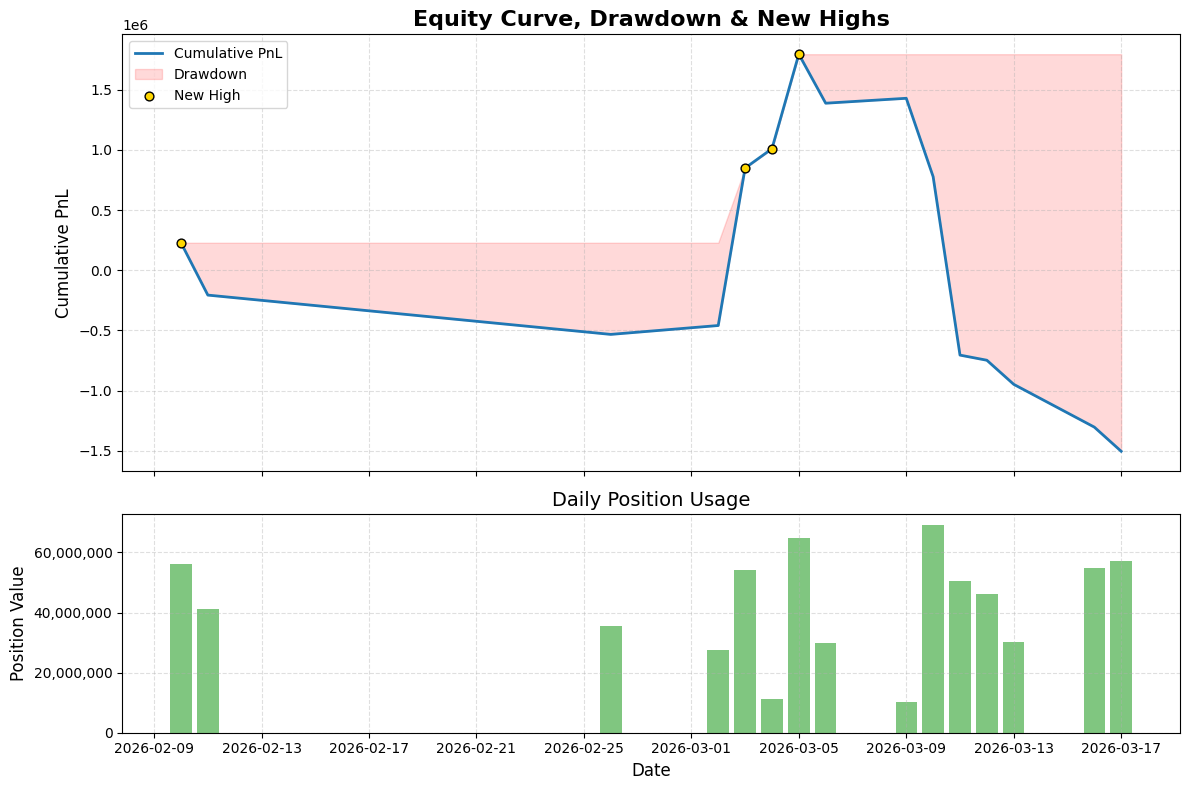


指標                 | 數值           

------------------ 基礎回報 ------------------
總報酬 (萬)           : -150.49
近一年報酬（萬）      : -150.49
風報比                  : -0.46
年化 Sharpe          : -2.53
創高最長費時 (天)     : 8
平均每日交易商品數   : 51.20

------------------ 勝率與效率 ------------------
年報酬率（基於平均部位）: -56.54%
近一年報酬率（近一年平均部位）: -3.53%
勝率 (日/單筆)      : 40.00% / 45.68%
平均BP (單/單位)   : -25.26 / -23.5601

------------------ 風控與部位 ------------------
單日最大虧損（萬） : -148.32 萬
MDD金額/佔平均比   : -330.05 萬 / 7.75%
平均/最大部位(萬)  : 4,258.24 / 6,923.37
平均最大單一商品比  : 3.22%



In [42]:
bt = BackTest(signalwithRisk_df)
results = bt.run_analysis()

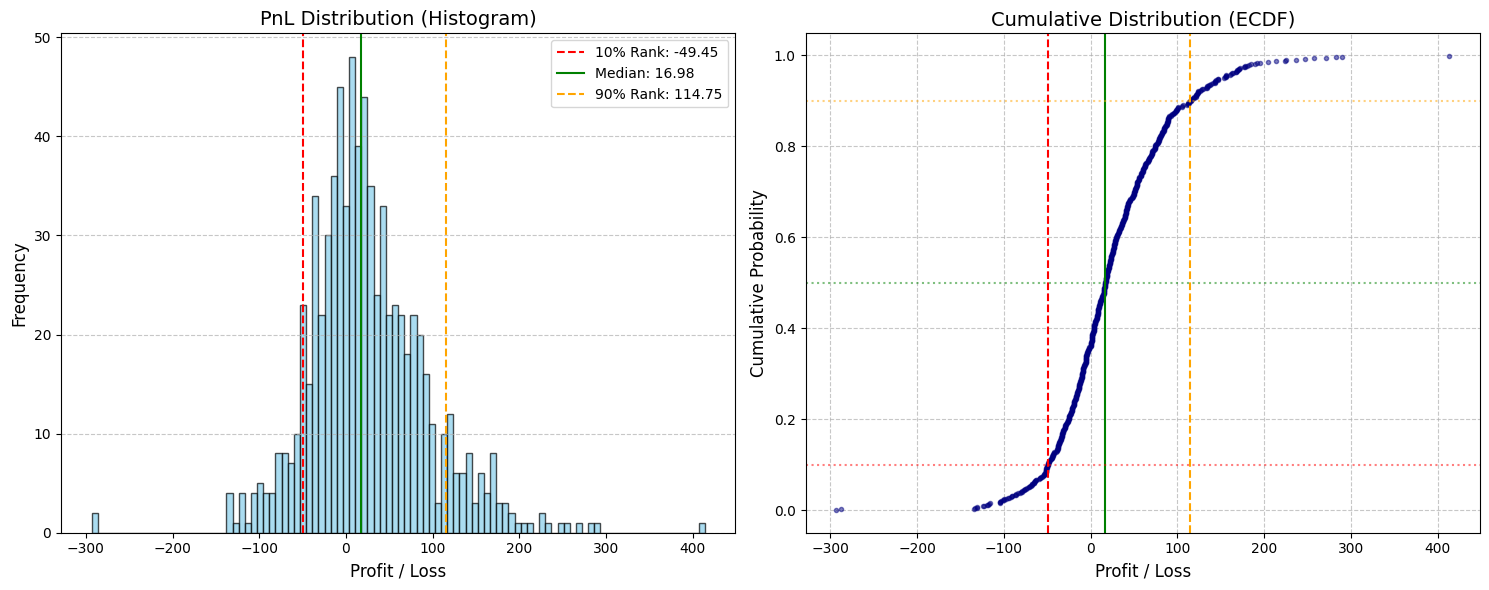

In [133]:

# 1. 計算分位數數值
q10 = series1.quantile(0.1)
q50 = series1.quantile(0.5)
q90 = series1.quantile(0.9)

# 2. 排序數據以計算累積機率 (ECDF)
sorted_data = np.sort(series1)
y_values = np.arange(len(sorted_data)) / float(len(sorted_data))

# 建立畫布
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- 圖左：直方圖 (棒狀圖) ---
axes[0].hist(series1, bins=100, color='skyblue', edgecolor='black', alpha=0.7)
# 加入垂直分界線
axes[0].axvline(q10, color='red', linestyle='--', linewidth=1.5, label=f'10% Rank: {q10:.2f}')
axes[0].axvline(q50, color='green', linestyle='-', linewidth=1.5, label=f'Median: {q50:.2f}')
axes[0].axvline(q90, color='orange', linestyle='--', linewidth=1.5, label=f'90% Rank: {q90:.2f}')

axes[0].set_title('PnL Distribution (Histogram)', fontsize=14)
axes[0].set_xlabel('Profit / Loss', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].legend() # 顯示圖例
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# --- 圖右：累積圖 (ECDF) ---
axes[1].plot(sorted_data, y_values, marker='.', linestyle='none', color='navy', alpha=0.5)
# 加入垂直分界線 (X軸：損益數值)
axes[1].axvline(q10, color='red', linestyle='--', linewidth=1.5)
axes[1].axvline(q50, color='green', linestyle='-', linewidth=1.5)
axes[1].axvline(q90, color='orange', linestyle='--', linewidth=1.5)
# 加入水平參考線 (Y軸：排名百分比)
axes[1].axhline(0.1, color='red', linestyle=':', alpha=0.5)
axes[1].axhline(0.5, color='green', linestyle=':', alpha=0.5)
axes[1].axhline(0.9, color='orange', linestyle=':', alpha=0.5)

axes[1].set_title('Cumulative Distribution (ECDF)', fontsize=14)
axes[1].set_xlabel('Profit / Loss', fontsize=12)
axes[1].set_ylabel('Cumulative Probability', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [134]:
# 計算所有天數的排名比例
series1 = ( signalwithRisk_df.BidPrice1 * (signalwithRisk_df.TakerSell_CloseBP - 19.3) / 10000 / 10).groupby(signalwithRisk_df.Date).sum()


In [135]:
date_portfolio = series1.reset_index().rename(columns={0: 'PL'})
date_portfolio['Position'] = ( signalwithRisk_df.BidPrice1 / 10).groupby(signalwithRisk_df.Date).sum().reset_index(drop=True)
date_portfolio['Return'] = date_portfolio['PL'] / date_portfolio['Position'] * 100

In [136]:
date_portfolio.describe()

,PL,Position,Return
count,763.000000,763.000000,763.000000
mean,24.642202,6657.419813,0.331335
std,69.091420,1915.726205,0.979506
min,-293.375112,95.600000,-4.473028
25%,-16.484015,5421.077500,-0.297200
50%,16.978363,6894.410000,0.267906
75%,60.406101,7959.225000,0.910252
max,413.550822,12201.030000,4.452573


In [137]:

from pathlib import Path
import os
PROJECT_ROOT = Path(os.path.abspath('')).parents[2]


dateData = []
for d in tqdm( date_portfolio.Date ) : 
    # 讀取 marketData
    maket_df = pd.read_parquet(f'{PROJECT_ROOT}/data/marketData/{d}_marketData.parquet')
    
    # 讀取 preMarketData (對應日期的每日特徵)
    premarket_df = pd.read_parquet(f'{PROJECT_ROOT}/data/preMarket/{d}_preMarketData.parquet')
    
    # 確保 key 都是字串型態以防合併錯誤
    maket_df['quote_code'] = maket_df['quote_code'].astype(str)
    premarket_df['QuoteCode'] = premarket_df['QuoteCode'].astype(str)
    
    # 合併兩個 DataFrame
    merged_df = pd.merge(
        maket_df, 
        premarket_df, 
        left_on='quote_code', 
        right_on='QuoteCode', 
        how='inner'
    )
    
    # 計算 toOpen
    merged_df['toOpen'] = (merged_df['open_price'] - merged_df['opening_ref_price']) / merged_df['opening_ref_price']
    merged_df['Return'] = (merged_df['close_price'] - merged_df['opening_ref_price']) / merged_df['opening_ref_price']

    tsmc = merged_df[merged_df['quote_code'] == '2330']
    tsmcOpen = tsmc.toOpen.iloc[0]
    tsmcReturn = tsmc.Return.iloc[0]
    # 2. day_amount_rank < 100 的 mean
    top_df = merged_df[merged_df['day_amount_rank'] < 100]
    topOpen = top_df.toOpen.mean(numeric_only=True)
    topDrop = top_df.toOpen.apply(np.sign).mean(numeric_only=True)
    topReturn = top_df.Return.mean(numeric_only=True)
    
    dateData.append( [tsmcOpen, tsmcReturn, topOpen, topDrop, topReturn])
    # break


100%|█████████▉| 762/763 [00:35<00:00, 21.54it/s]


KeyError: 'open_price'

In [138]:
date_portfolio = pd.concat( [date_portfolio, pd.DataFrame(columns=['tsmOpen', 'tsmReturn', 'topOpen', 'topDrop', 'topReturn'], data = dateData) ], axis = 1)

In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_qcut_analysis(df, col_a, col_b, date_col=None, split_date=None, q=5, isMin =False):
    """
    根據 col_a 的分位數繪製 col_b 的平均值。
    若提供 date_col 與 split_date，則會對比分割日期前後的表現。
    """
    # 1. 準備需要用的欄位，排除 NaN
    cols_to_keep = [col_a, col_b]
    if date_col is not None:
        cols_to_keep.append(date_col)
    
    temp_df = df[cols_to_keep].dropna().copy()
    
    # 2. 進行分箱 (qcut)
    temp_df['A_bins'] = pd.qcut(temp_df[col_a], q=q, duplicates='drop')
    
    # 判斷是否要進行時間分割
    do_split = (date_col is not None) and (split_date is not None)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # 內部標註數值函數
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            if pd.notna(height):
                va = 'bottom' if height >= 0 else 'top'
                offset = 3 if height >= 0 else -3
                ax.annotate(f'{height:.4f}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, offset),
                            textcoords="offset points",
                            ha='center', va=va, fontsize=9)

    if do_split:
        # --- 模式 A: 前後期分割對照 ---
        mask_before = temp_df[date_col] < split_date
        mean_before = temp_df[mask_before].groupby('A_bins')[col_b].mean()
        mean_after = temp_df[~mask_before].groupby('A_bins')[col_b].mean()
        
        all_bins = mean_before.index.union(mean_after.index)
        mean_before = mean_before.reindex(all_bins)
        mean_after = mean_after.reindex(all_bins)
        
        x_labels = [f"({interval.left:.3g}, {interval.right:.3g}]" for interval in all_bins]
        x = np.arange(len(x_labels))
        width = 0.35
        
        rects1 = ax.bar(x - width/2, mean_before.values, width, 
                        label=f'Before {split_date}', color='skyblue', edgecolor='black', alpha=0.8)
        rects2 = ax.bar(x + width/2, mean_after.values, width, 
                        label=f'After {split_date}', color='salmon', edgecolor='black', alpha=0.8)
        
        autolabel(rects1)
        autolabel(rects2)
        title = f'Comparison: Mean of {col_b} by {col_a} (Split by {split_date})'
        ax.legend(fontsize=11)
        
    else:
        # --- 模式 B: 全期間單一分組 ---
        if isMin : 
            mean_total = temp_df.groupby('A_bins')[col_b].min()
        else : 
            mean_total = temp_df.groupby('A_bins')[col_b].mean()

        x_labels = [f"({interval.left:.3g}, {interval.right:.3g}]" for interval in mean_total.index]
        x = np.arange(len(x_labels))
        
        rects = ax.bar(x, mean_total.values, 0.6, color='lightgray', edgecolor='black', alpha=0.8, label='Full Period')
        
        autolabel(rects)
        if isMin : 
            title = f'Analysis: Min of {col_b} by {col_a} (Full Period)'
        else : 
            title = f'Analysis: Mean of {col_b} by {col_a} (Full Period)'

    # 圖表美化
    ax.set_title(title, fontsize=14)
    ax.set_xlabel(f'{col_a} Bins', fontsize=12)
    ax.set_ylabel(f'Average {col_b}', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=45, ha='right')
    ax.axhline(0, color='gray', linewidth=1, linestyle='--')
    ax.grid(axis='y', linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

# --- 使用範例 ---
# 1. 只有分組繪圖 (不切日期)
# plot_qcut_analysis(df, 'Factor_A', 'Return')

# 2. 前後期對照 (切日期)
# plot_qcut_analysis(df, 'Factor_A', 'Return', date_col='Date', split_date=20240101)

In [306]:
date_portfolio['topStd_10D'] = (date_portfolio.topReturn).rolling(10,min_periods=1).std().shift()
# date_portfolio['topReturnlast_10D'] = (date_portfolio.topOpen).rolling(10,min_periods=1).min().shift()

In [330]:
date_portfolio['Count'] =  (date_portfolio.topOpen < 0.0018) | (date_portfolio.topReturnlast_10D < -0.025) 

<Axes: >

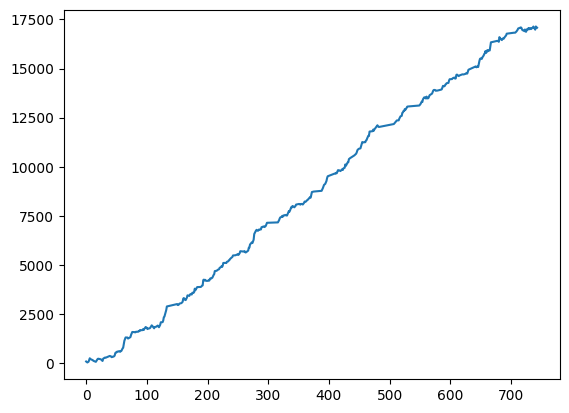

In [ ]:
date_portfolio[ date_portfolio ].PL.cumsum().plot()

In [332]:
abonraml_DATE = date_portfolio[ (date_portfolio.Count ==True) ].Date

In [333]:
abonraml_DATE

1      20230106
3      20230110
8      20230117
10     20230131
13     20230203
         ...   
758    20260311
759    20260312
760    20260313
761    20260316
762    20260317
Name: Date, Length: 352, dtype: str

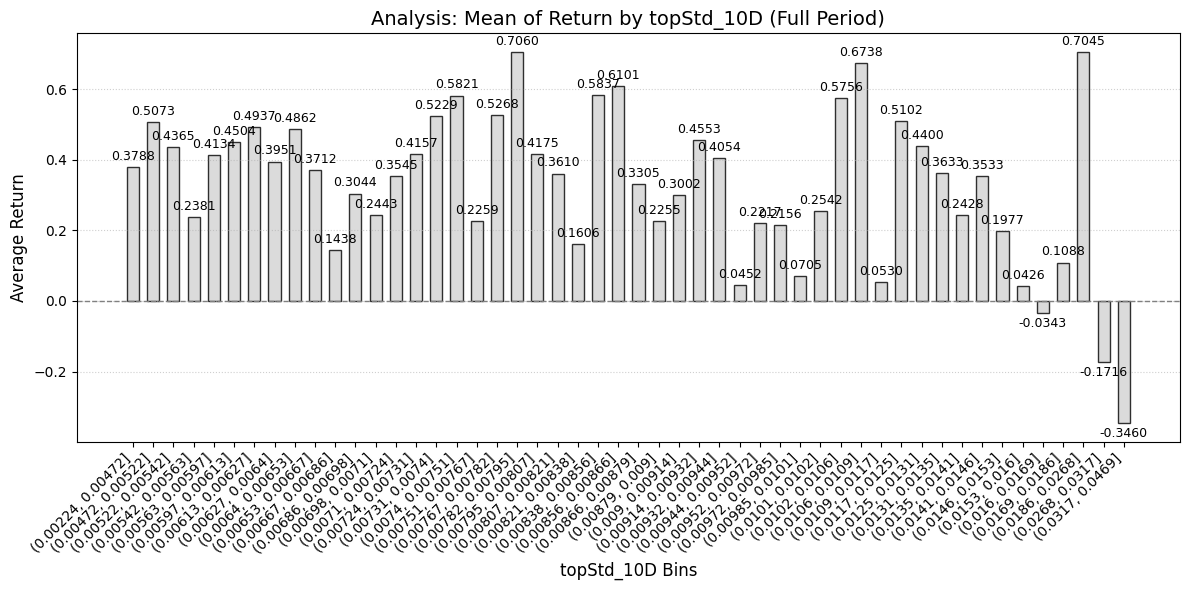

In [294]:
plot_qcut_analysis(date_portfolio, col_a='topStd_10D', col_b=f'Return', q=50 , isMin=False)

In [ ]:
date_portfolio[]

In [144]:
condition = date_portfolio.test > -0.005
print(condition.sum())
date_portfolio[ condition ].PL.cumsum().plot()

AttributeError: 'DataFrame' object has no attribute 'test'